# Neural Networks in JAX: Equinox and Flax

This tutorial covers the two main neural network libraries for JAX:

- **Equinox**: PyTree-based, minimal, integrates with diffrax/optimistix
- **Flax**: Google's library with Linen API, more feature-rich

## What You'll Learn

1. Equinox fundamentals (modules as PyTrees)
2. Flax Linen API
3. Common architectures (MLP, CNN, RNN)
4. Activation functions
5. Data preprocessing and normalization
6. Chemical engineering applications (surrogate models)

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random
import optax
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

# Neural network libraries
import equinox as eqx
import flax.linen as nn
from flax.training import train_state

print(f"JAX version: {jax.__version__}")
print(f"Equinox version: {eqx.__version__}")
print(f"Flax version: {nn.__version__ if hasattr(nn, '__version__') else 'installed'}")

JAX version: 0.8.2
Equinox version: 0.13.2
Flax version: installed


---
# Part 1: Equinox

Equinox treats neural networks as **PyTrees** - nested containers of arrays. This makes them work seamlessly with JAX transformations.

## Key Concepts

- `eqx.Module`: Base class for neural network layers
- `eqx.filter_*`: Functions to separate trainable from non-trainable parts
- Models are immutable - updates return new models

In [2]:
# Simple MLP in Equinox
class MLP(eqx.Module):
    """Multi-layer perceptron."""
    layers: list
    
    def __init__(self, in_size, hidden_sizes, out_size, key):
        """Initialize MLP with given architecture.
        
        Args:
            in_size: Input dimension
            hidden_sizes: List of hidden layer sizes
            out_size: Output dimension
            key: JAX random key
        """
        keys = random.split(key, len(hidden_sizes) + 1)
        
        sizes = [in_size] + hidden_sizes + [out_size]
        self.layers = []
        
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            self.layers.append(eqx.nn.Linear(n_in, n_out, key=keys[i]))
    
    def __call__(self, x):
        """Forward pass with ReLU activations."""
        for layer in self.layers[:-1]:
            x = jax.nn.relu(layer(x))
        return self.layers[-1](x)  # No activation on output

# Create model
key = random.PRNGKey(0)
model = MLP(in_size=2, hidden_sizes=[32, 32], out_size=1, key=key)

# Test forward pass
x = jnp.array([1.0, 2.0])
y = model(x)
print(f"Input: {x}")
print(f"Output: {y}")
print(f"\nModel structure: {jax.tree_util.tree_structure(model)}")

Input: [1. 2.]
Output: [0.18718683]

Model structure: PyTreeDef(CustomNode(MLP[('layers',), ()], [[CustomNode(Linear[('weight', 'bias'), (('in_features', 2), ('out_features', 32), ('use_bias', True))], [*, *]), CustomNode(Linear[('weight', 'bias'), (('in_features', 32), ('out_features', 32), ('use_bias', True))], [*, *]), CustomNode(Linear[('weight', 'bias'), (('in_features', 32), ('out_features', 1), ('use_bias', True))], [*, *])]]))


In [3]:
# Training with Equinox
# Generate synthetic data: y = sin(x1) + cos(x2)
key = random.PRNGKey(42)
X_train = random.uniform(key, (500, 2), minval=-3, maxval=3)
y_train = jnp.sin(X_train[:, 0]) + jnp.cos(X_train[:, 1])
y_train = y_train[:, None]  # Add dimension

# Loss function
def loss_fn(model, x, y):
    pred = vmap(model)(x)
    return jnp.mean((pred - y) ** 2)

# Training step using eqx.filter_grad
@eqx.filter_jit
def train_step(model, opt_state, x, y, optimizer):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# Initialize
model = MLP(in_size=2, hidden_sizes=[64, 64], out_size=1, key=random.PRNGKey(0))
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

# Training loop
losses = []
for epoch in range(500):
    model, opt_state, loss = train_step(model, opt_state, X_train, y_train, optimizer)
    losses.append(float(loss))
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss = {loss:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

Epoch 0: loss = 1.010908
Epoch 100: loss = 0.029374


Epoch 200: loss = 0.006564
Epoch 300: loss = 0.002573


Epoch 400: loss = 0.001385

Final loss: 0.000898


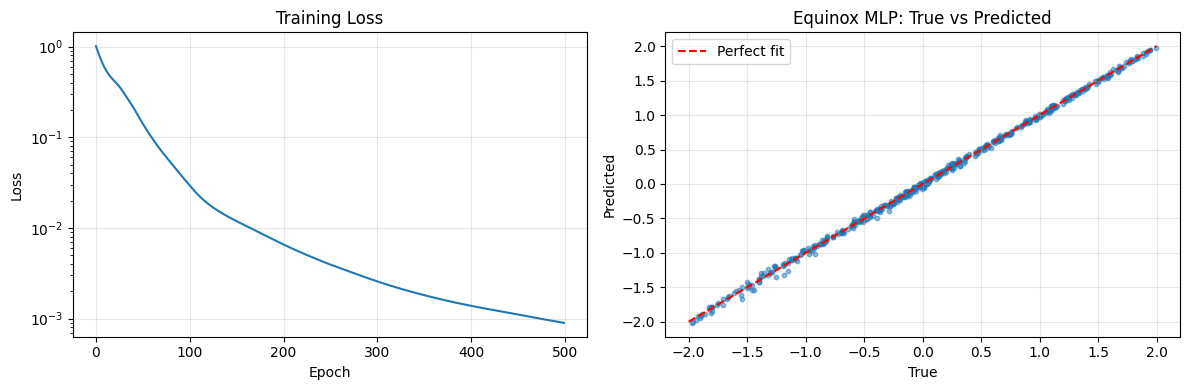

In [4]:
# Visualize Equinox model predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax = axes[0]
ax.semilogy(losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.grid(True, alpha=0.3)

# Predictions
ax = axes[1]
y_pred = vmap(model)(X_train)
ax.scatter(y_train, y_pred, alpha=0.5, s=10)
ax.plot([-2, 2], [-2, 2], 'r--', label='Perfect fit')
ax.set_xlabel('True')
ax.set_ylabel('Predicted')
ax.set_title('Equinox MLP: True vs Predicted')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Equinox Built-in Layers

| Layer | Description |
|-------|-------------|
| `eqx.nn.Linear` | Fully connected layer |
| `eqx.nn.Conv` | Convolution |
| `eqx.nn.ConvTranspose` | Transposed convolution |
| `eqx.nn.GRUCell`, `eqx.nn.LSTMCell` | Recurrent cells |
| `eqx.nn.MultiheadAttention` | Transformer attention |
| `eqx.nn.Embedding` | Embedding layer |
| `eqx.nn.BatchNorm`, `eqx.nn.LayerNorm` | Normalization |
| `eqx.nn.Dropout` | Dropout regularization |

In [5]:
# More complex Equinox architecture with normalization and dropout
class ResidualBlock(eqx.Module):
    """Residual block with layer normalization."""
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    norm: eqx.nn.LayerNorm
    dropout: eqx.nn.Dropout
    
    def __init__(self, size, key, dropout_rate=0.1):
        keys = random.split(key, 2)
        self.linear1 = eqx.nn.Linear(size, size, key=keys[0])
        self.linear2 = eqx.nn.Linear(size, size, key=keys[1])
        self.norm = eqx.nn.LayerNorm(size)
        self.dropout = eqx.nn.Dropout(dropout_rate)
    
    def __call__(self, x, *, key=None):
        # Pre-norm residual connection
        h = self.norm(x)
        h = jax.nn.gelu(self.linear1(h))
        if key is not None:
            h = self.dropout(h, key=key)
        h = self.linear2(h)
        return x + h  # Residual connection

class DeepResNet(eqx.Module):
    """Deep residual network."""
    input_proj: eqx.nn.Linear
    blocks: list
    output_proj: eqx.nn.Linear
    
    def __init__(self, in_size, hidden_size, out_size, n_blocks, key):
        keys = random.split(key, n_blocks + 2)
        self.input_proj = eqx.nn.Linear(in_size, hidden_size, key=keys[0])
        self.blocks = [ResidualBlock(hidden_size, keys[i+1]) for i in range(n_blocks)]
        self.output_proj = eqx.nn.Linear(hidden_size, out_size, key=keys[-1])
    
    def __call__(self, x, *, key=None):
        x = self.input_proj(x)
        if key is not None:
            keys = random.split(key, len(self.blocks))
            for block, k in zip(self.blocks, keys):
                x = block(x, key=k)
        else:
            for block in self.blocks:
                x = block(x, key=None)
        return self.output_proj(x)

# Create deep ResNet
resnet = DeepResNet(in_size=2, hidden_size=64, out_size=1, n_blocks=4, key=random.PRNGKey(0))
print(f"Deep ResNet created with 4 residual blocks")
print(f"Test output: {resnet(jnp.array([1.0, 2.0]))}")

Deep ResNet created with 4 residual blocks


Test output: [0.1040152]


---
# Part 2: Flax (Linen API)

Flax uses a different paradigm:
- Modules define `setup()` and `__call__()` methods
- Parameters are managed separately from the model
- More explicit parameter handling

In [6]:
# Simple MLP in Flax
class FlaxMLP(nn.Module):
    """Multi-layer perceptron in Flax."""
    hidden_sizes: tuple
    out_size: int
    
    @nn.compact
    def __call__(self, x):
        for size in self.hidden_sizes:
            x = nn.Dense(size)(x)
            x = nn.relu(x)
        x = nn.Dense(self.out_size)(x)
        return x

# Create model and initialize parameters
model = FlaxMLP(hidden_sizes=(64, 64), out_size=1)
key = random.PRNGKey(0)

# Initialize with dummy input
dummy_input = jnp.ones((1, 2))
params = model.init(key, dummy_input)

# Forward pass (params separate from model)
x = jnp.array([[1.0, 2.0]])
y = model.apply(params, x)
print(f"Input shape: {x.shape}")
print(f"Output: {y}")
print(f"\nParameter structure:")
print(jax.tree_util.tree_map(lambda x: x.shape, params))

Input shape: (1, 2)
Output: [[0.00910058]]

Parameter structure:
{'params': {'Dense_0': {'bias': (64,), 'kernel': (2, 64)}, 'Dense_1': {'bias': (64,), 'kernel': (64, 64)}, 'Dense_2': {'bias': (1,), 'kernel': (64, 1)}}}


In [7]:
# Training with Flax
def flax_loss_fn(params, model, x, y):
    pred = model.apply(params, x)
    return jnp.mean((pred - y) ** 2)

def make_flax_train_step(model, optimizer):
    """Create a JIT-compiled train step for a specific model and optimizer."""
    @jit
    def train_step(params, opt_state, x, y):
        loss, grads = jax.value_and_grad(lambda p: flax_loss_fn(p, model, x, y))(params)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss
    return train_step

# Initialize
model = FlaxMLP(hidden_sizes=(64, 64), out_size=1)
params = model.init(random.PRNGKey(0), jnp.ones((1, 2)))
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

# Create train step for this model and optimizer
flax_train_step = make_flax_train_step(model, optimizer)

# Training loop
losses = []
for epoch in range(500):
    params, opt_state, loss = flax_train_step(params, opt_state, X_train, y_train)
    losses.append(float(loss))
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss = {loss:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

Epoch 0: loss = 1.336300
Epoch 100: loss = 0.184707


Epoch 200: loss = 0.039805
Epoch 300: loss = 0.017218


Epoch 400: loss = 0.008397

Final loss: 0.004036


## Flax Built-in Layers

| Layer | Description |
|-------|-------------|
| `nn.Dense` | Fully connected |
| `nn.Conv` | Convolution |
| `nn.ConvTranspose` | Transposed convolution |
| `nn.RNN`, `nn.GRU`, `nn.LSTM` | Recurrent layers |
| `nn.MultiHeadDotProductAttention` | Transformer attention |
| `nn.Embed` | Embedding |
| `nn.BatchNorm`, `nn.LayerNorm` | Normalization |
| `nn.Dropout` | Dropout |

In [8]:
# Advanced Flax architecture: CNN for 1D signals
class CNN1D(nn.Module):
    """1D CNN for time series / spectral data."""
    features: tuple = (32, 64, 128)
    kernel_size: int = 3
    out_size: int = 1
    
    @nn.compact
    def __call__(self, x, training: bool = True):
        # x shape: (batch, length, channels)
        for feat in self.features:
            x = nn.Conv(features=feat, kernel_size=(self.kernel_size,))(x)
            x = nn.BatchNorm(use_running_average=not training)(x)
            x = nn.relu(x)
            x = nn.max_pool(x, window_shape=(2,), strides=(2,))
        
        # Global average pooling
        x = jnp.mean(x, axis=1)
        
        # Dense layers
        x = nn.Dense(64)(x)
        x = nn.relu(x)
        x = nn.Dense(self.out_size)(x)
        return x

# Test CNN
cnn = CNN1D(features=(16, 32), out_size=1)
dummy_signal = jnp.ones((4, 64, 1))  # (batch, length, channels)
variables = cnn.init(random.PRNGKey(0), dummy_signal)
output = cnn.apply(variables, dummy_signal, training=False)
print(f"CNN input shape: {dummy_signal.shape}")
print(f"CNN output shape: {output.shape}")

CNN input shape: (4, 64, 1)
CNN output shape: (4, 1)


---
# Part 3: Activation Functions

JAX provides many activation functions in `jax.nn`:

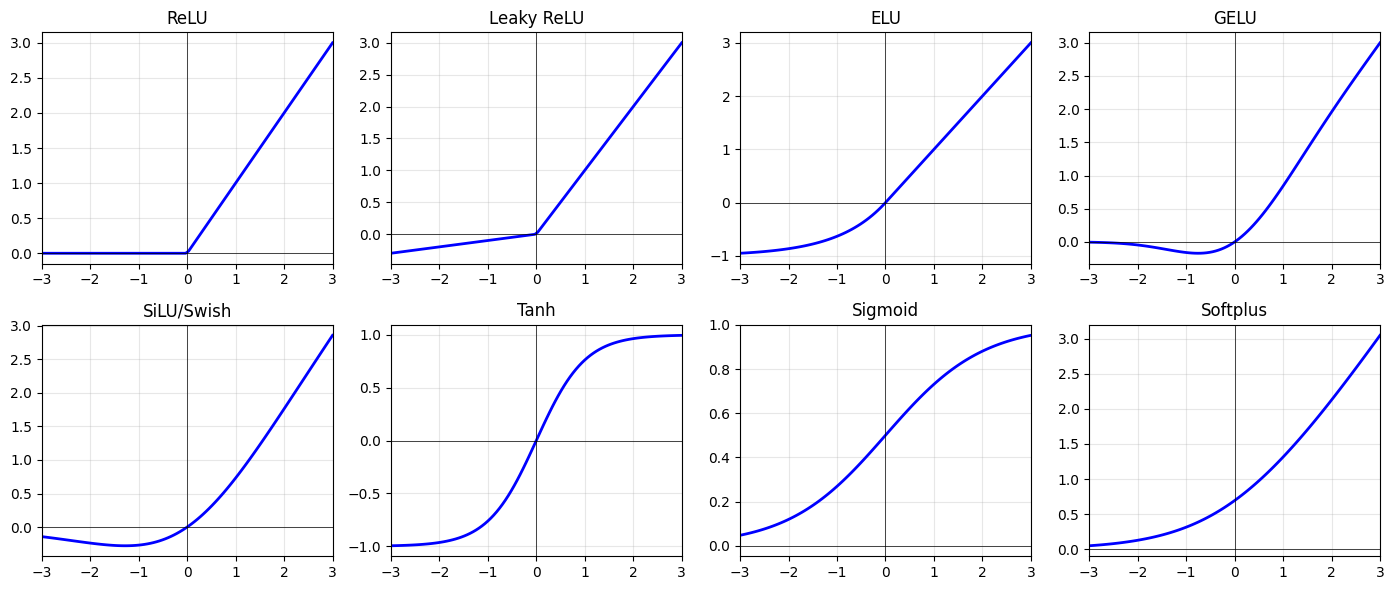

Activation function recommendations:
  - General: GELU or SiLU (smooth, modern)
  - Fast: ReLU (simple, efficient)
  - Bounded output: Tanh or Sigmoid
  - Positive output: Softplus or ReLU


In [9]:
# Common activation functions
x = jnp.linspace(-3, 3, 100)

activations = {
    'ReLU': jax.nn.relu,
    'Leaky ReLU': lambda x: jax.nn.leaky_relu(x, negative_slope=0.1),
    'ELU': jax.nn.elu,
    'GELU': jax.nn.gelu,
    'SiLU/Swish': jax.nn.silu,
    'Tanh': jnp.tanh,
    'Sigmoid': jax.nn.sigmoid,
    'Softplus': jax.nn.softplus,
}

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for ax, (name, fn) in zip(axes, activations.items()):
    y = fn(x)
    ax.plot(x, y, 'b-', linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(name)
    ax.set_xlim(-3, 3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Activation function recommendations:")
print("  - General: GELU or SiLU (smooth, modern)")
print("  - Fast: ReLU (simple, efficient)")
print("  - Bounded output: Tanh or Sigmoid")
print("  - Positive output: Softplus or ReLU")

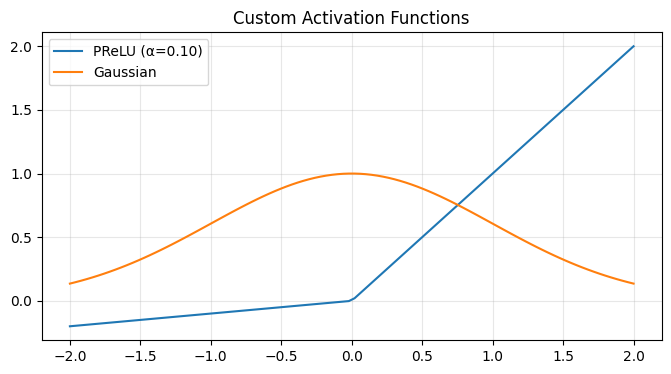

In [10]:
# Custom activation: parametric activation
class ParametricReLU(eqx.Module):
    """Learnable negative slope."""
    alpha: jax.Array
    
    def __init__(self, init_alpha=0.25):
        self.alpha = jnp.array(init_alpha)
    
    def __call__(self, x):
        return jnp.where(x > 0, x, self.alpha * x)

# Gaussian activation (useful for radial basis functions)
def gaussian_activation(x, sigma=1.0):
    return jnp.exp(-x**2 / (2 * sigma**2))

# Test
prelu = ParametricReLU(init_alpha=0.1)
x = jnp.linspace(-2, 2, 100)
plt.figure(figsize=(8, 4))
plt.plot(x, prelu(x), label=f'PReLU (α={float(prelu.alpha):.2f})')
plt.plot(x, gaussian_activation(x), label='Gaussian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Custom Activation Functions')
plt.show()

---
# Part 4: Data Preprocessing

Proper preprocessing is critical for neural network training.

In [11]:
# Preprocessing utilities
class StandardScaler:
    """Standardize features: (x - mean) / std"""
    def __init__(self):
        self.mean = None
        self.std = None
    
    def fit(self, X):
        self.mean = jnp.mean(X, axis=0)
        self.std = jnp.std(X, axis=0) + 1e-8  # Avoid division by zero
        return self
    
    def transform(self, X):
        return (X - self.mean) / self.std
    
    def inverse_transform(self, X):
        return X * self.std + self.mean
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

class MinMaxScaler:
    """Scale to [0, 1] range."""
    def __init__(self, feature_range=(0, 1)):
        self.min = None
        self.max = None
        self.feature_range = feature_range
    
    def fit(self, X):
        self.min = jnp.min(X, axis=0)
        self.max = jnp.max(X, axis=0)
        return self
    
    def transform(self, X):
        X_scaled = (X - self.min) / (self.max - self.min + 1e-8)
        lo, hi = self.feature_range
        return X_scaled * (hi - lo) + lo
    
    def inverse_transform(self, X):
        lo, hi = self.feature_range
        X_scaled = (X - lo) / (hi - lo)
        return X_scaled * (self.max - self.min) + self.min

class LogScaler:
    """Log transform for positive data spanning orders of magnitude."""
    def __init__(self, offset=1e-8):
        self.offset = offset
    
    def transform(self, X):
        return jnp.log(X + self.offset)
    
    def inverse_transform(self, X):
        return jnp.exp(X) - self.offset

In [12]:
# Example: Preprocessing for chemical engineering data
# Generate synthetic reaction rate data (spans orders of magnitude)
key = random.PRNGKey(0)
n_samples = 200

# Features: Temperature (K), Pressure (bar), Concentration (mol/L)
T = random.uniform(key, (n_samples,), minval=300, maxval=600)
P = random.uniform(random.PRNGKey(1), (n_samples,), minval=1, maxval=100)
C = random.uniform(random.PRNGKey(2), (n_samples,), minval=0.01, maxval=10)

# Target: Reaction rate (Arrhenius-like, spans many orders of magnitude)
k = 1e8 * jnp.exp(-5000 / T) * P**0.5 * C

X_raw = jnp.stack([T, P, C], axis=1)
y_raw = k[:, None]

print("Raw data ranges:")
print(f"  T: {float(T.min()):.1f} - {float(T.max()):.1f} K")
print(f"  P: {float(P.min()):.1f} - {float(P.max()):.1f} bar")
print(f"  C: {float(C.min()):.2f} - {float(C.max()):.2f} mol/L")
print(f"  k: {float(k.min()):.2e} - {float(k.max()):.2e} (rate)")

Raw data ranges:


  T: 301.3 - 598.5 K
  P: 1.0 - 99.8 bar
  C: 0.11 - 9.90 mol/L
  k: 2.12e+01 - 1.36e+06 (rate)


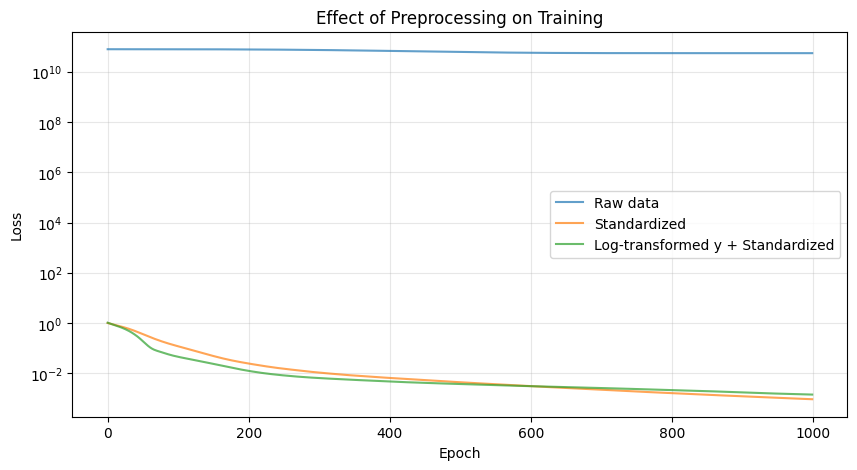

Final losses:
  Raw: 5.54e+10
  Standardized: 9.37e-04
  Log + Standardized: 1.43e-03


In [13]:
# Compare training with different preprocessing
def train_model(X, y, name, epochs=1000):
    """Train MLP and return losses."""
    model = MLP(in_size=3, hidden_sizes=[32, 32], out_size=1, key=random.PRNGKey(0))
    optimizer = optax.adam(1e-3)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    
    losses = []
    for _ in range(epochs):
        model, opt_state, loss = train_step(model, opt_state, X, y, optimizer)
        losses.append(float(loss))
    
    return losses

# No preprocessing
losses_raw = train_model(X_raw, y_raw, "Raw")

# StandardScaler
scaler_X = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(y_raw)
X_std = scaler_X.transform(X_raw)
y_std = scaler_y.transform(y_raw)
losses_std = train_model(X_std, y_std, "Standardized")

# Log transform for y (since it spans orders of magnitude)
log_scaler = LogScaler()
y_log = log_scaler.transform(y_raw)
scaler_y_log = StandardScaler().fit(y_log)
y_log_std = scaler_y_log.transform(y_log)
losses_log = train_model(X_std, y_log_std, "Log-transformed")

# Plot comparison
plt.figure(figsize=(10, 5))
plt.semilogy(losses_raw, label='Raw data', alpha=0.7)
plt.semilogy(losses_std, label='Standardized', alpha=0.7)
plt.semilogy(losses_log, label='Log-transformed y + Standardized', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Effect of Preprocessing on Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final losses:")
print(f"  Raw: {losses_raw[-1]:.2e}")
print(f"  Standardized: {losses_std[-1]:.2e}")
print(f"  Log + Standardized: {losses_log[-1]:.2e}")

---
# Part 5: Chemical Engineering Application

## Surrogate Model for a CSTR

Train a neural network to predict reactor outlet composition from operating conditions.

In [14]:
# Generate CSTR training data
def cstr_steady_state(T, tau, C_A0):
    """Steady-state CSTR for first-order reaction A -> B.
    
    Args:
        T: Temperature (K)
        tau: Residence time (s)
        C_A0: Feed concentration (mol/L)
    
    Returns:
        C_A: Outlet concentration of A
        X: Conversion
    """
    # Arrhenius rate constant
    k = 1e6 * jnp.exp(-6000 / T)  # 1/s
    
    # CSTR design equation: C_A = C_A0 / (1 + k*tau)
    C_A = C_A0 / (1 + k * tau)
    X = 1 - C_A / C_A0
    
    return C_A, X

# Generate dataset
n_samples = 1000
key = random.PRNGKey(42)
keys = random.split(key, 3)

T_data = random.uniform(keys[0], (n_samples,), minval=300, maxval=500)
tau_data = random.uniform(keys[1], (n_samples,), minval=10, maxval=1000)
C_A0_data = random.uniform(keys[2], (n_samples,), minval=0.1, maxval=5.0)

C_A_data, X_data = vmap(cstr_steady_state)(T_data, tau_data, C_A0_data)

# Prepare features and targets
X_features = jnp.stack([T_data, tau_data, C_A0_data], axis=1)
y_targets = jnp.stack([C_A_data, X_data], axis=1)

print(f"Dataset: {n_samples} samples")
print(f"Features: T, tau, C_A0")
print(f"Targets: C_A, X (conversion)")

Dataset: 1000 samples
Features: T, tau, C_A0
Targets: C_A, X (conversion)


In [15]:
# Build and train surrogate model
class CSTRSurrogate(eqx.Module):
    """Surrogate model for CSTR."""
    layers: list
    input_scaler_mean: jax.Array
    input_scaler_std: jax.Array
    output_scaler_mean: jax.Array
    output_scaler_std: jax.Array
    
    def __init__(self, key, X_train, y_train):
        # Store scaling parameters
        self.input_scaler_mean = jnp.mean(X_train, axis=0)
        self.input_scaler_std = jnp.std(X_train, axis=0) + 1e-8
        self.output_scaler_mean = jnp.mean(y_train, axis=0)
        self.output_scaler_std = jnp.std(y_train, axis=0) + 1e-8
        
        # Build network
        keys = random.split(key, 4)
        self.layers = [
            eqx.nn.Linear(3, 64, key=keys[0]),
            eqx.nn.Linear(64, 64, key=keys[1]),
            eqx.nn.Linear(64, 32, key=keys[2]),
            eqx.nn.Linear(32, 2, key=keys[3]),
        ]
    
    def __call__(self, x):
        # Normalize input
        x = (x - self.input_scaler_mean) / self.input_scaler_std
        
        # Forward pass
        for layer in self.layers[:-1]:
            x = jax.nn.gelu(layer(x))
        x = self.layers[-1](x)
        
        # Denormalize output
        x = x * self.output_scaler_std + self.output_scaler_mean
        
        # Physical constraints: C_A > 0, 0 < X < 1
        C_A = jax.nn.softplus(x[0])  # Ensure positive
        X = jax.nn.sigmoid(x[1])      # Ensure in (0, 1)
        
        return jnp.array([C_A, X])

# Split data
n_train = 800
X_train, X_test = X_features[:n_train], X_features[n_train:]
y_train, y_test = y_targets[:n_train], y_targets[n_train:]

# Create model
surrogate = CSTRSurrogate(random.PRNGKey(0), X_train, y_train)

# Custom loss for scaled training
def surrogate_loss(model, x, y):
    pred = vmap(model)(x)
    # Relative error for better scaling
    rel_error = (pred - y) / (jnp.abs(y) + 1e-6)
    return jnp.mean(rel_error ** 2)

@eqx.filter_jit
def surrogate_train_step(model, opt_state, x, y, optimizer):
    loss, grads = eqx.filter_value_and_grad(surrogate_loss)(model, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# Train
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(surrogate, eqx.is_array))

losses = []
for epoch in range(2000):
    surrogate, opt_state, loss = surrogate_train_step(
        surrogate, opt_state, X_train, y_train, optimizer
    )
    losses.append(float(loss))
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: loss = {loss:.6f}")

print(f"\nFinal training loss: {losses[-1]:.6f}")

Epoch 0: loss = 404796.363017


Epoch 500: loss = 58.510534


Epoch 1000: loss = 15.157902


Epoch 1500: loss = 6.439167



Final training loss: 3.317600


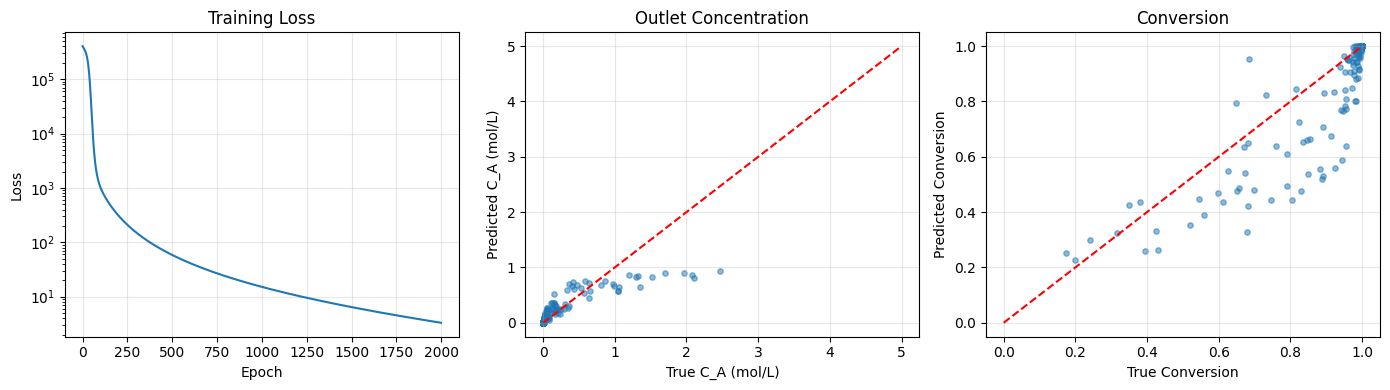

Test MAE - C_A: 0.0989 mol/L
Test MAE - X: 0.0577


In [16]:
# Evaluate surrogate model
y_pred_test = vmap(surrogate)(X_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Training loss
ax = axes[0]
ax.semilogy(losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.grid(True, alpha=0.3)

# C_A prediction
ax = axes[1]
ax.scatter(y_test[:, 0], y_pred_test[:, 0], alpha=0.5, s=15)
ax.plot([0, 5], [0, 5], 'r--')
ax.set_xlabel('True C_A (mol/L)')
ax.set_ylabel('Predicted C_A (mol/L)')
ax.set_title('Outlet Concentration')
ax.grid(True, alpha=0.3)

# Conversion prediction
ax = axes[2]
ax.scatter(y_test[:, 1], y_pred_test[:, 1], alpha=0.5, s=15)
ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlabel('True Conversion')
ax.set_ylabel('Predicted Conversion')
ax.set_title('Conversion')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute metrics
mae_CA = jnp.mean(jnp.abs(y_test[:, 0] - y_pred_test[:, 0]))
mae_X = jnp.mean(jnp.abs(y_test[:, 1] - y_pred_test[:, 1]))
print(f"Test MAE - C_A: {float(mae_CA):.4f} mol/L")
print(f"Test MAE - X: {float(mae_X):.4f}")

In [17]:
# Use surrogate for optimization: Find conditions for target conversion
# This demonstrates differentiating through the surrogate

def optimization_objective(inputs, surrogate, target_X, C_A0):
    """Find T and tau to achieve target conversion."""
    T, tau = inputs
    x = jnp.array([T, tau, C_A0])
    _, X_pred = surrogate(x)
    return (X_pred - target_X) ** 2

# Target: 90% conversion with C_A0 = 2 mol/L
target_X = 0.9
C_A0 = 2.0

# Optimize using gradient descent through the surrogate
inputs = jnp.array([400.0, 100.0])  # Initial guess: T=400K, tau=100s
optimizer = optax.adam(1.0)
opt_state = optimizer.init(inputs)

for i in range(200):
    loss, grads = jax.value_and_grad(optimization_objective)(inputs, surrogate, target_X, C_A0)
    updates, opt_state = optimizer.update(grads, opt_state, inputs)
    inputs = optax.apply_updates(inputs, updates)
    
    # Clip to valid ranges
    inputs = jnp.clip(inputs, jnp.array([300., 10.]), jnp.array([500., 1000.]))

T_opt, tau_opt = inputs
_, X_achieved = surrogate(jnp.array([T_opt, tau_opt, C_A0]))

print(f"Optimization result for {target_X:.0%} conversion:")
print(f"  Temperature: {float(T_opt):.1f} K")
print(f"  Residence time: {float(tau_opt):.1f} s")
print(f"  Achieved conversion: {float(X_achieved):.1%}")

# Verify with true model
_, X_true = cstr_steady_state(T_opt, tau_opt, C_A0)
print(f"  True conversion: {float(X_true):.1%}")

Optimization result for 90% conversion:
  Temperature: 399.3 K
  Residence time: 99.3 s
  Achieved conversion: 90.0%


  True conversion: 96.7%


---
# Summary

## Equinox vs Flax

| Aspect | Equinox | Flax |
|--------|---------|------|
| Philosophy | Models are PyTrees | Separate params/model |
| Syntax | More Pythonic | More explicit |
| Integration | diffrax, optimistix | TensorBoard, Orbax |
| Learning curve | Gentler | Steeper |
| Community | Growing | Larger (Google) |

## Activation Function Guidelines

| Activation | Use When |
|------------|----------|
| ReLU | Fast training, simple problems |
| GELU/SiLU | Modern architectures, smooth gradients |
| Tanh | Bounded outputs, RNNs |
| Sigmoid | Binary outputs, gates |
| Softplus | Positive outputs (e.g., rates, concentrations) |

## Preprocessing Guidelines

| Data Type | Recommended |
|-----------|-------------|
| General | StandardScaler |
| Bounded [0,1] | MinMaxScaler |
| Orders of magnitude | LogScaler + StandardScaler |
| Positive rates | LogScaler for target |

## Resources

- Equinox: https://docs.kidger.site/equinox/
- Flax: https://flax.readthedocs.io/
- JAX activations: `jax.nn` module